In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# KV caching: reuse an unchanged causal prefix

Chapter 4 · Session 3. We replay six fixed feature vectors through two residual attention layers. This is a small computation-graph example, not a pretrained Transformer and not free text generation. It deliberately omits norms, MLPs, and positional encodings. The output head has five arbitrary classes.

The goal is equality: incremental cached computation should match recomputing each full prefix.

In [2]:
from pathlib import Path
import sys
import math
import torch
import torch.nn.functional as F
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/dongxi_llms/attention_evidence.py').exists())
if str(root / 'src') not in sys.path: sys.path.insert(0, str(root / 'src'))
from dongxi_llms.causal_attention_lab import attention_trace, teaching_inputs
from dongxi_llms.attention_evidence import gradient_evidence, scaling_evidence, cache_fixture, full_stack, decode_step, cache_evidence
torch.set_printoptions(precision=5, sci_mode=False)
print('PyTorch', torch.__version__, '| CPU float64')

PyTorch 2.14.1+cpu | CPU float64


## 1. Prediction: what is the identity of a cache entry?

If the input vector at the second position is identical in two sequences but the first position changes, must that second position have identical keys at every layer?

In [3]:
prediction_identity = ""

### Reference solution

In this example, the first-layer projection is positionwise, so the identical second input has an identical first-layer key. After one causal attention update it can depend on the changed earlier position; its second-layer key may differ. This clarifies why context matters without claiming that every first-layer Q/K/V already contains contextual information.

In [4]:
x, layers, head = cache_fixture()
changed = x.clone()
changed[0] += 3
_, original = full_stack(x[:2], layers, head)
_, altered = full_stack(changed[:2], layers, head)
for layer in range(len(layers)):
    error = (original[layer][0][1] - altered[layer][0][1]).abs().max().item()
    print('Layer', layer+1, '| second-position key difference:', error)
print('Identical second input:', torch.equal(x[1], changed[1]))

Layer 1 | second-position key difference: 0.0
Layer 2 | second-position key difference: 2.0491642070647273
Identical second input: True


## 2. Implementation: prefill and one new query

Prefill two positions with `full_stack`. The result includes one K/V pair per layer. For the next position calculate q, append its k/v, and use q to read all available keys. Why do past queries not appear in this step?

The query is at the last global position. All provided cache positions are allowed. A naive 1×N lower-triangular mask would incorrectly keep only the first key.

In [5]:
def my_last_query(q, old_k, old_v, new_k, new_v):
    all_k = ...
    all_v = ...
    weights = ...
    return weights @ all_v
run_my_step = False

### Reference solution

The new query determines today's retrieval. Past keys provide addresses and past values supply messages. Old queries have already completed their retrievals. Reuse applies to each layer's incoming states, so caches must stay separate across layers.

In [6]:
def reference_last_query(q, old_k, old_v, new_k, new_v):
    all_k = torch.cat([old_k, new_k], dim=0)
    all_v = torch.cat([old_v, new_v], dim=0)
    weights = (q @ all_k.T / math.sqrt(q.shape[-1])).softmax(-1)
    return weights @ all_v

_, caches = full_stack(x[:2], layers, head)
wq, wk, wv = layers[0]
arguments = (x[2:3] @ wq, *caches[0], x[2:3] @ wk, x[2:3] @ wv)
print('First-layer retrieval:', reference_last_query(*arguments))
if run_my_step:
    torch.testing.assert_close(my_last_query(*arguments), reference_last_query(*arguments))
actual, updated = decode_step(x[2:3], caches, layers, head)
expected, _ = full_stack(x[:3], layers, head)
print('Cached logits:', actual)
print('Full-prefix logits:', expected[-1:])
torch.testing.assert_close(actual, expected[-1:], atol=1e-12, rtol=1e-12)

First-layer retrieval: tensor([[ 0.50252, -0.13052, -1.05730, -0.50877]], dtype=torch.float64)
Cached logits: tensor([[ 2.17662, -0.98055,  1.80455, -1.23809, -1.44551]],
       dtype=torch.float64)
Full-prefix logits: tensor([[ 2.17662, -0.98055,  1.80455, -1.23809, -1.44551]],
       dtype=torch.float64)


## 3. Prediction and verification: append repeatedly

Should numerical agreement hold only for the first new token, or for every extension? State the assumptions: fixed parameters, correct layer-specific state, compatible positions, unchanged prefix, no dropout, and compatible numerical execution.

In [7]:
prediction_equivalence = ""

### Reference solution

The argument repeats at each layer and each new position. Earlier causal states are unchanged, their stored projections remain valid, and each new row can be computed using them. Small rounding differences are possible between execution strategies; we test at a declared tolerance.

In [8]:
_, caches = full_stack(x[:2], layers, head)
for t in range(2, len(x)):
    actual, caches = decode_step(x[t:t+1], caches, layers, head)
    expected, _ = full_stack(x[:t+1], layers, head)
    difference = (actual - expected[-1:]).abs().max().item()
    print('Position', t, '| max error:', difference, '| K shapes:', [tuple(k.shape) for k, _ in caches])
    torch.testing.assert_close(actual, expected[-1:], atol=1e-12, rtol=1e-12)

Position 2 | max error: 4.440892098500626e-16 | K shapes: [(3, 4), (3, 4)]
Position 3 | max error: 3.3306690738754696e-16 | K shapes: [(4, 4), (4, 4)]
Position 4 | max error: 2.7755575615628914e-17 | K shapes: [(5, 4), (5, 4)]
Position 5 | max error: 0.0 | K shapes: [(6, 4), (6, 4)]


## 4. Break it: reuse the wrong prefix

Reuse the old two-position cache after changing the first input. The next input row is unchanged. Can the runtime repair the prefix by processing just that new row?

In [9]:
prediction_stale = ""

### Reference solution

No. The old keys/values represent the original prefix and propagate its state. Recompute the changed prefix (or its affected suffix with a valid earlier cache). Token identity alone does not authorize cache reuse.

In [10]:
_, stale = full_stack(x[:2], layers, head)
stale_logits, _ = decode_step(changed[2:3], stale, layers, head)
correct, _ = full_stack(changed[:3], layers, head)
error = (stale_logits - correct[-1:]).abs().max().item()
print('Stale-cache logit error:', error)
assert error > 1e-6

Stale-cache logit error: 1.8069073123097426


## 5. Accounting: what was saved, and what grows?

Predict which grows as positions accumulate: parameter count, stored K/V bytes, or the number of keys the next query reads?

In [11]:
prediction_cost = ""

### Reference solution

The model's parameter count is unchanged. Logical K/V storage and next-query attention work grow with the retained sequence. For this equal-width single-head fixture, bytes=2×layers×positions×width×bytes_per_scalar. This counts tensor payload, not allocator-reserved memory.

With a two-position prefill followed by four one-position appends, caching projects 12 layer-position rows. Recomputing prefixes of lengths 2,3,4,5,6 projects 40. These are work counts for K or V projections; they are not measured speedup factors.

In [12]:
result = cache_evidence()
print(result)
logical_bytes = sum(k.numel()*k.element_size() + v.numel()*v.element_size() for k, v in caches)
print('Final logical cache bytes:', logical_bytes)
assert logical_bytes == 2 * 2 * 6 * 4 * 8 == 768

{'decode_errors': [4.440892098500626e-16, 3.3306690738754696e-16, 2.7755575615628914e-17, 0.0], 'cache_bytes': [384, 512, 640, 768], 'final_shapes': [[6, 4], [6, 4]], 'first_layer_same_token_key_error': 0.0, 'second_layer_same_token_key_error': 2.0491642070647273, 'stale_cache_logit_error': 1.8069073123097426, 'cached_projected_rows': 12, 'uncached_projected_rows': 40}
Final logical cache bytes: 768


## 6. Lifecycle and evidence boundary

What happens when generation ends? Does releasing the cache necessarily reduce memory reported by the GPU allocator?

In [13]:
my_cache_boundary = ""

### Reference solution

A completed request no longer needs its cache. Removing the runtime's references permits tensor storage to be freed or reused, but an allocator may retain reserved memory. Some serving systems retain compatible exact prefixes for reuse in later requests. A later conversation turn needs retained state or prefix recomputation.

Our replay verifies two-layer mathematical reuse under fixed execution. It does not benchmark serving frameworks, prove cache reuse under parameter changes, or test positional encodings, beams, eviction, or quantization. See the [chapter](../../book/chapters/04-attention-and-the-causal-information-boundary.md) and [worked solutions](../../book/solutions/04-attention-and-the-causal-information-boundary.md).

## Visual extension — what caching saves and what still grows

Prediction: As a fixed causal sequence extends, do stored parameters, logical cache bytes and repeated projection work grow in the same way?

Make your explanation before running the plot.

### Reference explanation and reading guide

The left panel measures logical K/V payload from each fixture prefix. The right panel counts layer-position rows projected by cached appends versus complete prefix replay. These are tensor/work counts, not measured GPU speedups or allocator usage. The replay assertions check output equivalence at the stated tolerance.

Saved reference preview (generated 2026-10-04):

![Visual extension — what caching saves and what still grows](../figures/chapter-04/day-04-03_kv_cache_equivalence-01.png)

The preview is fixed; rerun the following cell to regenerate figures from the current reference tensors. Matplotlib is required for this optional visual extension.

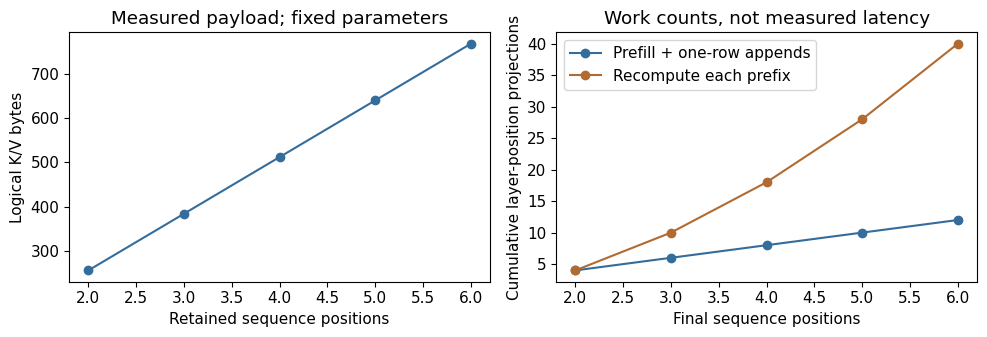

Cached/full logit errors: [4.440892098500626e-16, 3.3306690738754696e-16, 2.7755575615628914e-17, 0.0]


In [14]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
                     "font.family":"DejaVu Sans","font.size":11})
visual_x,visual_layers,visual_head=cache_fixture()
visual_lengths=list(range(2,len(visual_x)+1)); visual_bytes=[]; visual_errors=[]
_,visual_cache=full_stack(visual_x[:2],visual_layers,visual_head)
for length in visual_lengths:
    full,full_cache=full_stack(visual_x[:length],visual_layers,visual_head)
    visual_bytes.append(sum(k.numel()*k.element_size()+v.numel()*v.element_size() for k,v in full_cache))
    if length>2:
        incremental,visual_cache=decode_step(visual_x[length-1:length],visual_cache,visual_layers,visual_head)
        error=float((incremental-full[-1:]).abs().max()); visual_errors.append(error)
        assert error<1e-12
visual_layer_count=len(visual_layers)
visual_cached=[visual_layer_count*length for length in visual_lengths]
visual_replay=[visual_layer_count*sum(range(2,length+1)) for length in visual_lengths]
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].plot(visual_lengths,visual_bytes,"o-",color="#346c9c")
axes[0].set(xlabel="Retained sequence positions",ylabel="Logical K/V bytes",title="Measured payload; fixed parameters")
axes[1].plot(visual_lengths,visual_cached,"o-",label="Prefill + one-row appends",color="#346c9c")
axes[1].plot(visual_lengths,visual_replay,"o-",label="Recompute each prefix",color="#b16b31")
axes[1].set(xlabel="Final sequence positions",ylabel="Cumulative layer-position projections",title="Work counts, not measured latency")
axes[1].legend(); plt.tight_layout(); plt.show()
print("Cached/full logit errors:",visual_errors)
assert visual_bytes[-1]==768 and visual_cached[-1]==12 and visual_replay[-1]==40